SECTION 1: Problem Statement

# Customer Segmentation & Retention Analysis
## Business Problem
A financial service company is losing customers and cannot identify who is at risk until it is to late. This project segments customers by behaviour, predicts churn probability, and calculates Customer Lifetime Value (CLV) to help the business prioritize retention efforts.

## Fraud Detection Connection
Churning customers and fradulent accounts share behavioral fingerprints: declining transaction frequency, reduced balance utilization, and sudden inactivity. the risk scoring model in this project is a precursor to fraud detection systems used in real financial institutions.

## Key Business Questions
1. Which customer segments are most at risk of churning?
2. What behavioral patterns predict churn 90 days in advance?
3. Which customers are worth retaining based on their lifetime value?
4. What actions should the business take for each segment?


SECTION 2: Install and Import Libraries

In [24]:
# Install any missing libraries
!pip install scikit-learn pandas numpy matplotlib seaborn plotly -q

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


SECTION 3: Load and Explore the Data

In [25]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/DataScience_Projects Project1/BankChurners.csv')

# Drop the last two columns (they are model leakage columns  kaggle flagged)
df = df.iloc[:, :-2]

# First look
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (10127, 21)

Column Names:
 ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

First 5 rows:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [26]:
# Data types and missing values
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nChurn Distribution:\n", df['Attrition_Flag'].value_counts())

Data Types:
 CLIENTNUM                     int64
Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

Missing Values:
 CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status     

In [27]:
# Summary statistics
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


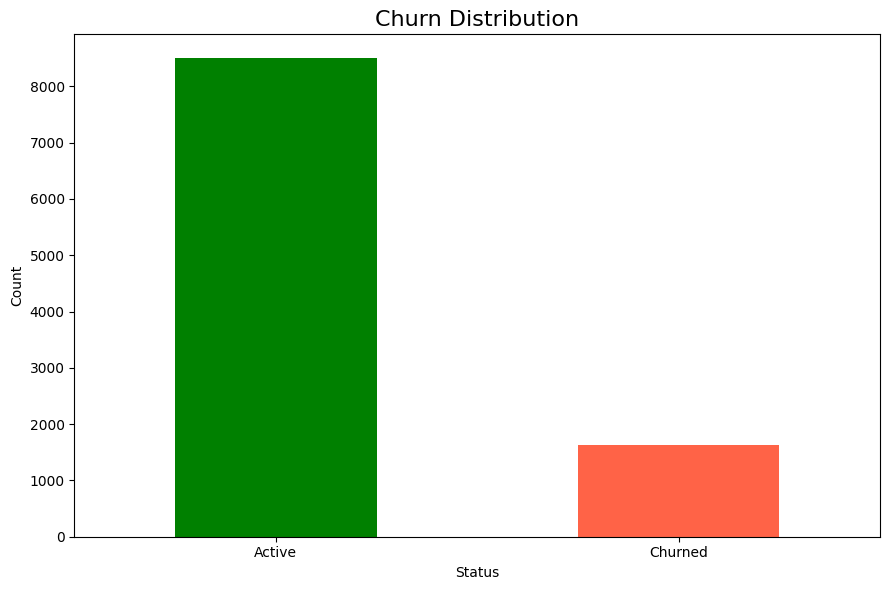

Churned customers: 1627
Churn rate: 16.07 %


In [28]:
# Visualize churn distribution
fig, ax = plt.subplots(figsize=(9, 6))
df['Attrition_Flag'].value_counts().plot(kind='bar', color=['green', 'tomato'], ax=ax)
ax.set_title('Churn Distribution', fontsize=16)
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.set_xticklabels(['Active', 'Churned'], rotation=0)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()
print("Churned customers:", (df['Attrition_Flag'] == 'Attrited Customer').sum())
print("Churn rate:", round((df['Attrition_Flag'] == 'Attrited Customer').mean() * 100, 2), "%")


SECTION 4: Data Cleaning and Feature Engineering

In [29]:
# Encode the target variable
df['Churn'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Encode categorical columns
categorical_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

le = LabelEncoder()
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df[col])

print("Encoding complete")
df_encoded.head()

Encoding complete


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,768805383,Existing Customer,45,1,3,3,1,2,0,39,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,818770008,Existing Customer,49,0,5,2,2,4,0,44,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,713982108,Existing Customer,51,1,3,2,1,3,0,36,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,769911858,Existing Customer,40,0,4,3,3,4,0,34,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,709106358,Existing Customer,40,1,3,5,1,2,0,21,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


In [30]:
# Feature Engineering - craete new business-relevant features

# Transaction intensity: how active is the customer
df_encoded['Transaction_Intensity'] = (df_encoded['Total_Trans_Amt'] / (df_encoded['Total_Trans_Ct'] + 1))

# Credit utilization ratio
df_encoded['Credit_Utilization'] = (df_encoded['Total_Revolving_Bal'] / (df_encoded['Credit_Limit'] + 1))

#Inactivity score: months inactive relative to relationship length
df_encoded['Inactivity_Score'] = (df_encoded['Months_Inactive_12_mon'] / (df_encoded['Months_on_book'] + 1))

# Contact frequency: how often has the bank reached out
df_encoded['Contact_Frequency'] = df_encoded['Contacts_Count_12_mon']

print("New Features created: Transaction_Intensity, Credit_Utilization, Inactivity_Score")
df_encoded[['Transaction_Intensity', 'Credit_Utilization', 'Inactivity_Score', 'Churn']].describe()

New Features created: Transaction_Intensity, Credit_Utilization, Inactivity_Score


,Transaction_Intensity,Credit_Utilization,Inactivity_Score,Churn
count,10127.000000,10127.000000,10127.000000,10127.000000
mean,61.573946,0.274796,0.066503,0.160660
std,26.244708,0.275570,0.032980,0.367235
min,18.813559,0.000000,0.000000,0.000000
25%,46.509259,0.022713,0.043478,0.000000
50%,54.857143,0.175613,0.063830,0.000000
75%,64.327076,0.502524,0.081081,0.000000
max,188.056180,0.998358,0.428571,1.000000


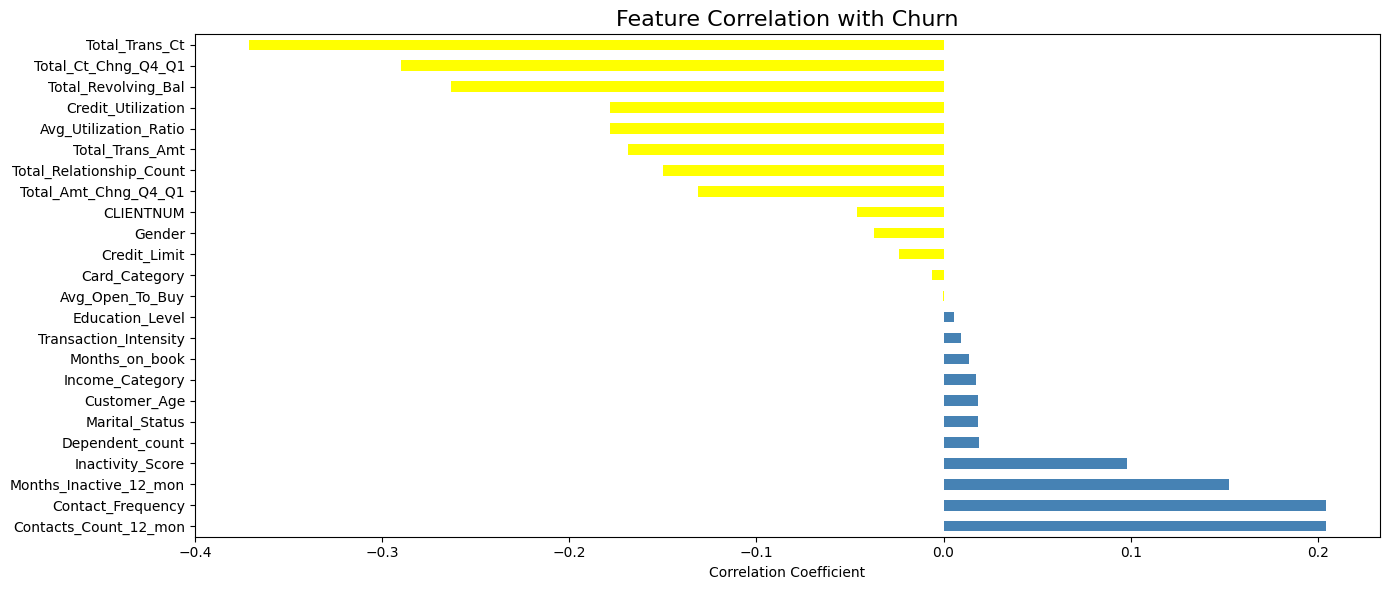

In [31]:
# Correlation heatmap to understand which features relate to churn
numeric_df = df_encoded.select_dtypes(include=[np.number])
churn_corr = numeric_df.corr() ['Churn'].sort_values(ascending=False)

plt.figure(figsize=(14, 6))
churn_corr.drop('Churn').plot(kind='barh', color=['yellow' if x < 0 else 'steelblue' for x in churn_corr.drop('Churn')])
plt.title('Feature Correlation with Churn', fontsize=16)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig('churn_correlation.png', dpi=150)
plt.show()

SECTION 5: Customer Segmentation with K-Means

In [32]:
# Select features for clustering
cluster_features = ['Total_Trans_Amt', 'Total_Trans_Ct', 'Credit_Utilization', 'Inactivity_Score', 'Transaction_Intensity', 'Months_on_book', 'Total_Relationship_Count']
X_cluster = df_encoded[cluster_features].copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Features scaled. Shape:", X_scaled.shape)

Features scaled. Shape: (10127, 7)


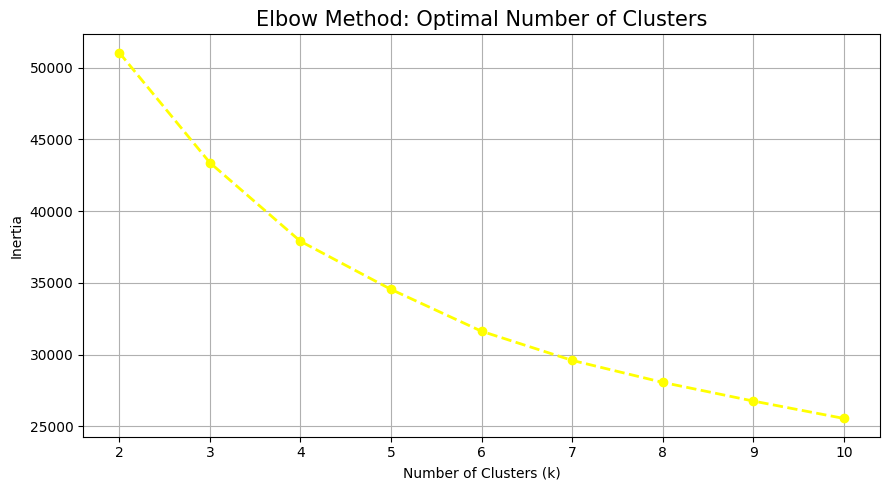

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

In [33]:
# Find the optimal number of clusters using the Elbow Method
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='yellow', linewidth=2)
plt.title('Elbow Method: Optimal Number of Clusters', fontsize=15)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()
plt

In [34]:
# Apply K-Means with K=4 (you will see the elbow at 4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_encoded['Segment'] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df_encoded['Segment'].value_counts())


Cluster sizes:
Segment
1    4332
2    2712
3    1693
0    1390
Name: count, dtype: int64


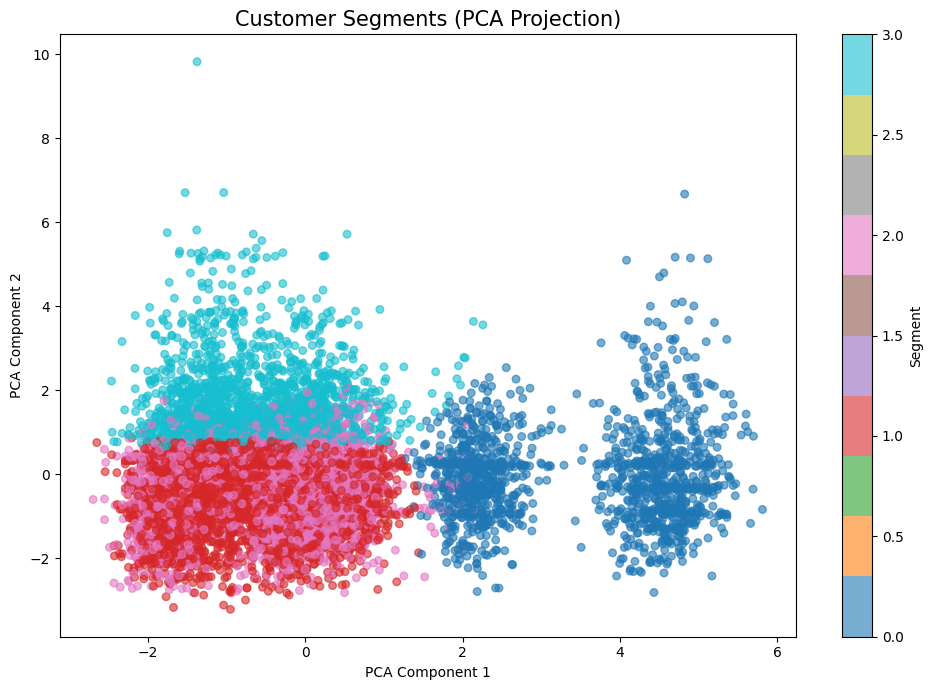

In [35]:
# Visualize clusters using PCA (reduce to 2D for plotting)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_encoded['PCA1'] = X_pca[:, 0]
df_encoded['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_encoded['PCA1'], df_encoded['PCA2'], c=df_encoded['Segment'], cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, label='Segment')
plt.title('Customer Segments (PCA Projection)', fontsize=15)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('customer_segments_pca.png', dpi=150)
plt.show()

In [36]:
# Profile each segment
segment_profile = df_encoded.groupby('Segment')[cluster_features + ['Churn']].mean().round(3)
print("Segment Profiles:")
segment_profile


Segment Profiles:


,Total_Trans_Amt,Total_Trans_Ct,Credit_Utilization,Inactivity_Score,Transaction_Intensity,Months_on_book,Total_Relationship_Count,Churn
Segment,,,,,,,,
0,11661.453,98.008,0.160,0.065,117.195,35.324,2.238,0.150
1,3011.882,55.975,0.096,0.056,51.952,38.657,4.043,0.217
2,3683.257,65.152,0.632,0.058,54.818,37.829,3.975,0.079
3,3162.609,59.904,0.254,0.109,51.349,26.400,4.257,0.157


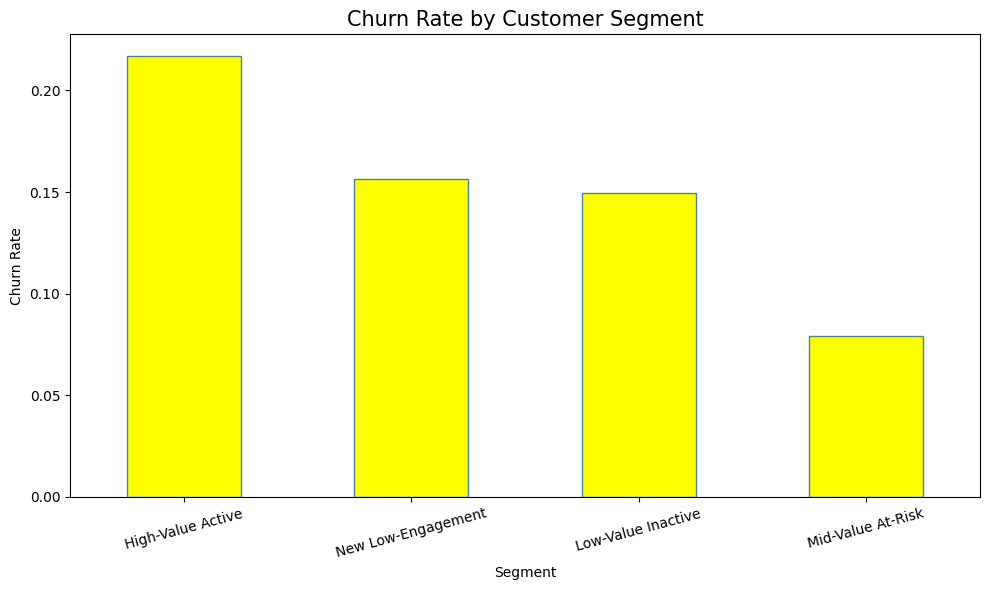

In [37]:
# Name the segments based on their profiles
segment_names = {
    0: 'Low-Value Inactive',
    1: 'High-Value Active',
    2: 'Mid-Value At-Risk',
    3: 'New Low-Engagement'
}
# Note: reassign these names after reviewing your actual segment_profile output
# The names above are illustrative.
df_encoded['Segment_Name'] = df_encoded['Segment'].map(segment_names)

# Churn rate by segment
churn_by_segment = df_encoded.groupby('Segment_Name')['Churn'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
churn_by_segment.plot(kind='bar', color='yellow', edgecolor='steelblue')
plt.title('Churn Rate by Customer Segment', fontsize=15)
plt.ylabel('Churn Rate')
plt.xlabel('Segment')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('churn_by_segment.png', dpi=150)
plt.show()

SECTION 6: Churn Prediction Model

In [38]:
# Define features and target
feature_cols = ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level',
              'Marital_Status', 'Income_Category', 'Card_Category',
              'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
              'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
              'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
              'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
              'Transaction_Intensity', 'Credit_Utilization', 'Inactivity_Score', 'Segment'
              ]
X = df_encoded[feature_cols]
y = df_encoded['Churn']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42, stratify=y)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("Churn rate in training set:", round(y_train.mean() * 100, 2), "%")

Training size: (8101, 23)
Testing size: (2026, 23)
Churn rate in training set: 16.07 %


In [39]:
# Train three models and compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model' : model, 'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}
    print(f"{name} - AUC: {round(auc, 4)}")



Logistic Regression - AUC: 0.9144
Random Forest - AUC: 0.9868
Gradient Boosting - AUC: 0.9881


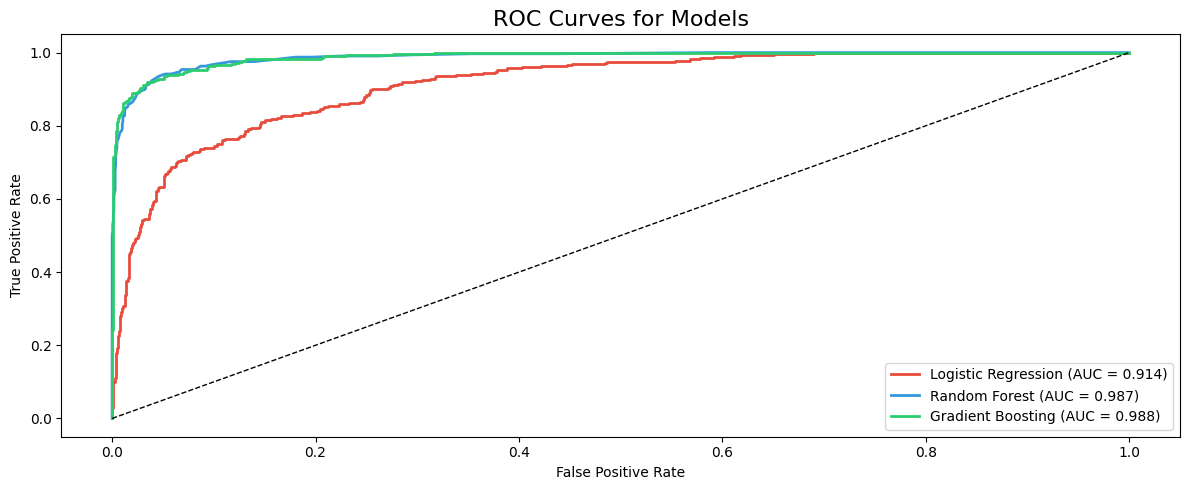

In [40]:
import matplotlib.pyplot as plt

# Plot ROC curves for all three models
plt.figure(figsize=(12, 5))

colors = {'Logistic Regression': '#e74c3c', # red
          'Random Forest': '#3498db', # blue
          'Gradient Boosting': '#2ecc71' # green
          }

for name, result in results.items():
  fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
  plt.plot(fpr, tpr, label=f"{name} (AUC = {round(result['auc'], 3)})", linewidth=2, color=colors[name])


plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curves for Models', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

Classification Report - Random Forest:
              precision    recall  f1-score   support

      Active       0.97      0.99      0.98      1701
     Churned       0.94      0.82      0.88       325

    accuracy                           0.96      2026
   macro avg       0.95      0.91      0.93      2026
weighted avg       0.96      0.96      0.96      2026



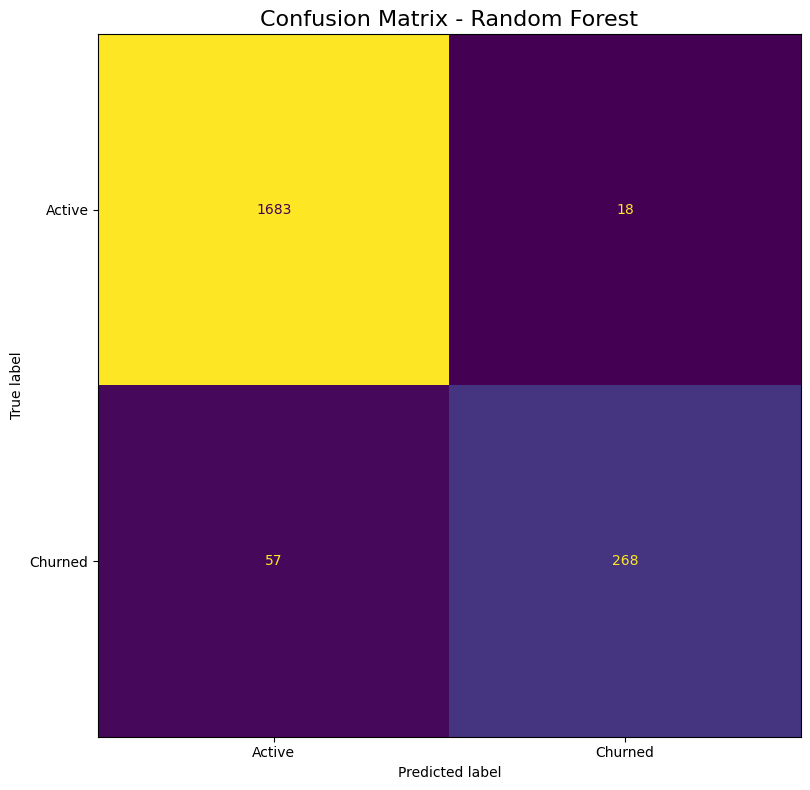

In [41]:
# Best model: use model Random Forest (typically wins here)
best_model = results['Random Forest']['model']
y_pred_best = results['Random Forest']['y_pred']

# Classification report
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_best, target_names=['Active', 'Churned']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best,
                      display_labels=['Active', 'Churned'], colorbar=False, ax=ax)

plt.title('Confusion Matrix - Random Forest', fontsize=16)
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150)
plt.show()


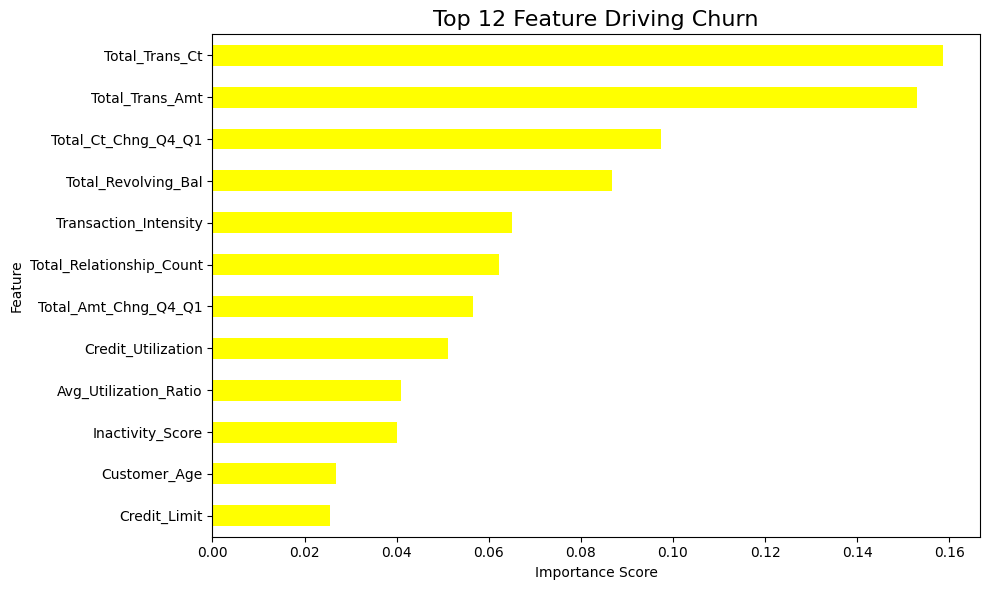

In [42]:
# Feature importance
importances = pd.Series(best_model.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='yellow')
plt.title('Top 12 Feature Driving Churn', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

SECTION 7: Customer Lifetime Value (CLV)

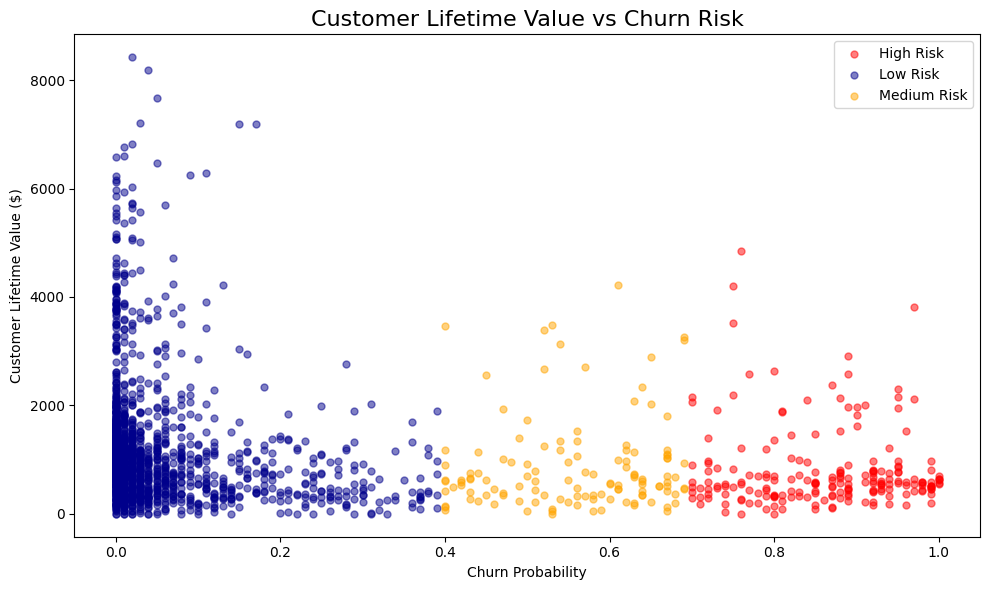

In [43]:
# Simple CLV calculation
# CLV = Average Monthly Spend * Expected Months Remaining * Profit Margin

avg_monthly_spend = df_encoded['Total_Trans_Amt'] / 12
expected_months = df_encoded['Months_on_book'].max() - df_encoded['Months_on_book']
profit_margin = 0.15 # industry avaerage for financial services

df_encoded['CLV'] = (avg_monthly_spend * expected_months * profit_margin).round(2)

# Assign churn risk score (probability from best model)
df_encoded_test = df_encoded.loc[X_test.index].copy()
df_encoded_test['Churn_Probability'] = results['Random Forest']['y_prob']

# Risk category
def risk_label(prob):
  if prob >= 0.7:
      return 'High Risk'
  elif prob >= 0.4:
      return 'Medium Risk'
  else:
      return 'Low Risk'

df_encoded_test['Risk_Category'] = df_encoded_test['Churn_Probability'].apply(risk_label)

# CLV vs Churn Risk scatter
plt.figure(figsize=(10, 6))
colors = {'High Risk': 'red', 'Medium Risk': 'orange', 'Low Risk': 'darkblue'}
for risk, group in df_encoded_test.groupby('Risk_Category'):
    plt.scatter(group['Churn_Probability'], group['CLV'],
                label=risk, alpha=0.5, s=25, color=colors[risk])

plt.title('Customer Lifetime Value vs Churn Risk', fontsize=16)
plt.xlabel('Churn Probability')
plt.ylabel('Customer Lifetime Value ($)')
plt.legend()
plt.tight_layout()
plt.savefig('clv_vs_churn_risk.png', dpi=150)
plt.show()

In [44]:
# Business priority matrix: high CLV + high risk = act now
priority = df_encoded_test[
    (df_encoded_test['Risk_Category'] == 'High Risk') &
    (df_encoded_test['CLV'] > df_encoded_test['CLV'].median())
].sort_values('CLV', ascending=False)

print("High-Priority Retention Targets:")
print(f"Total: {len(priority)} customers")
print(f"Average CLV: ${priority['CLV'].mean():.2f}")
print(f"Average Churn Probability: {priority['Churn_Probability'].mean():.2%}")
priority[['CLV', 'Churn_Probability', 'Risk_Category', 'Segment_Name']].head(10)


High-Priority Retention Targets:
Total: 43 customers
Average CLV: $1951.95
Average Churn Probability: 84.42%


,CLV,Churn_Probability,Risk_Category,Segment_Name
9458,4845.48,0.76,High Risk,Low-Value Inactive
10112,4202.10,0.75,High Risk,Low-Value Inactive
9975,3823.46,0.97,High Risk,Low-Value Inactive
9768,3528.35,0.75,High Risk,Low-Value Inactive
10050,2906.48,0.89,High Risk,Low-Value Inactive
9777,2642.90,0.80,High Risk,Low-Value Inactive
10118,2577.50,0.77,High Risk,Low-Value Inactive
10124,2572.75,0.89,High Risk,Low-Value Inactive
9756,2381.00,0.87,High Risk,Low-Value Inactive
9916,2303.00,0.95,High Risk,Low-Value Inactive


SECTION 8: Business Recommendations

## Business Recommendations

### Segment Actions

| Segment | Churn Risk | CLV | Recommended Action |
|---|---|---|---|
| High-Value Active | Low | High | Loyalty rewards, upsell premium cards |
| Mid-Value At-Risk | High | Medium | Proactive outreach, retention offers |
| Low-Value Inactive | High | Low | Low-cost reactivation campaigns |
| New Low-Engagement | Medium | Low | Onboarding improvement, early engagement |

### Model Results
- Best Model: Random Forest
- AUC Score: 0.987
- The top churn predictors are transaction count changes, inactivity months, and contact frequency

### Fraud Detection Link
The same inactivity and transaction behavior features that predict churn are used in fraud detection models. Customers showing sudden inactivity combined with high contact frequency match early fraud indicators in financical crime literature.

### Estimated Business Impact
- Retaining 10% of high-risk, high-CLV customers could recover significant annual revenue
- Early identification (90 days ahead) gives thr retention team actionable lead time

